#  Medical Insurance Cost Prediction
## Notebook 2 — Preprocessing & Feature Selection

---
**Input :** `data/raw/insurance.csv`  
**Output:** `data/processed/`  
**Target:** `annual_medical_cost`



<a id='1'></a>
## 1. Setup & Imports

In [4]:
pip install boruta

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 4.9 MB/s eta 0:00:00


In [5]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.patches import Patch

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from boruta import BorutaPy

import os
import joblib

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'axes.titleweight': 'bold'})

RANDOM_STATE = 55
TARGET       = 'annual_medical_cost'

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../models', exist_ok=True)
os.makedirs('../reports/figures', exist_ok=True)

<a id='2'></a>
## 2. Load Raw Data

In [7]:
df = pd.read_csv('/content/medical_insurance.csv')

# person_id drop
df.drop(columns=['person_id'], inplace=True, errors='ignore')

# Data Deduplication
n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)

print(f'Shape         : {df.shape}')
print(f'Duplicates    : {n_before - len(df)} row has been deleted')
print(f'Missing values: {df.isnull().sum().sum()}')
df.head(3)

Shape         : (100000, 53)
Duplicates    : 0 row has been deleted
Missing values: 30083


,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,1,...,0,1,0,1,0,2,0,1,0,0
1,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,1,...,0,1,1,0,0,1,0,1,1,0
2,68,Male,North,Rural,40700.0,HS,Married,Retired,5,3,...,0,0,1,1,0,2,1,0,1,0


###  Data Leakage — Removed Columns

**Data leakage** occurs when features used during model training contain information
that would not be available at prediction time — causing the model to appear more
accurate than it truly is in production.

The following columns are removed before modeling:

| Column | Reason |
|--------|--------|
| `annual_premium` | Directly derived from the target; would not be known before cost is calculated |
| `monthly_premium` | Same as above — a direct transformation of `annual_premium` |
| `total_claims_paid` | This is an *outcome* of medical cost, not a predictor of it |
| `avg_claim_amount` | Computed after claims are filed — unavailable at prediction time |
| `claims_count` | Known only after the insurance period ends |

> Keeping these columns would inflate model performance metrics and produce
> a model that fails entirely on real-world unseen data.

In [1]:
#Column Classification
#Columns with Data Leakage Risk relative to the Target
LEAKAGE_COLS = [
    'annual_premium',
    'monthly_premium',
    'total_claims_paid',
    'avg_claim_amount',
    'claims_count',
]

NUM_COLS = [
    'age', 'income', 'household_size', 'dependents', 'bmi',
    'visits_last_year', 'hospitalizations_last_3yrs',
    'days_hospitalized_last_3yrs', 'medication_count',
    'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c',
    'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs',
    'provider_quality', 'risk_score', 'chronic_count',
    'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count',
    'proc_consult_count', 'proc_lab_count'
]

BINARY_COLS = [
    'hypertension', 'diabetes', 'asthma', 'copd',
    'cardiovascular_disease', 'cancer_history', 'kidney_disease',
    'liver_disease', 'arthritis', 'mental_health',
    'is_high_risk', 'had_major_procedure'
]

CAT_COLS = [
    'sex', 'region', 'urban_rural', 'education',
    'marital_status', 'employment_status', 'smoker',
    'plan_type', 'network_tier',
    'alcohol_freq'
]

print(f'Numerical columns   : {len(NUM_COLS)}')
print(f'Binary columns      : {len(BINARY_COLS)}')
print(f'Categorical columns : {len(CAT_COLS)}')
print(f'Data leakage columns: {LEAKAGE_COLS}')

Numerical columns   : 25
Binary columns      : 12
Categorical columns : 10
Data leakage columns: ['annual_premium', 'monthly_premium', 'total_claims_paid', 'avg_claim_amount', 'claims_count']


<a id='3'></a>
## 3. Outlier Detection & Handling

> **Strateji:** IQR yontemiyle aykiri degerleri tespit edip `clip` uyguluyoruz.  
> 100k satirda veri kaybini onlemek icin silmek yerine clip tercih edildi.  
> `annual_medical_cost` kolonu clip'e dahil edilmedi — log transform alacak.

In [8]:
def iqr_bounds(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

outlier_report = []
for col in NUM_COLS + [TARGET]:
    lo, hi = iqr_bounds(df[col])
    n_out  = ((df[col] < lo) | (df[col] > hi)).sum()
    outlier_report.append({
        'Feature': col,
        'Outlier Count': n_out,
        'Outlier %': f'{n_out/len(df)*100:.2f}%',
        'Lower': round(lo, 2),
        'Upper': round(hi, 2)
    })

outlier_df = pd.DataFrame(outlier_report)
print('Outlier report (only columns with outliers):')
display(outlier_df[outlier_df['Outlier Count'] > 0])

Outlier report (only columns with outliers):


,Feature,Outlier Count,Outlier %,Lower,Upper
0,age,864,0.86%,5.50,89.50
1,income,6236,6.24%,-40550.00,123850.00
2,household_size,4052,4.05%,0.50,4.50
3,dependents,6306,6.31%,-1.50,2.50
4,bmi,676,0.68%,13.40,40.60
5,visits_last_year,2083,2.08%,-2.00,6.00
6,hospitalizations_last_3yrs,8969,8.97%,0.00,0.00
7,days_hospitalized_last_3yrs,8969,8.97%,0.00,0.00
8,medication_count,492,0.49%,-3.00,5.00
9,systolic_bp,613,0.61%,75.50,159.50


In [10]:
print(df[NUM_COLS + [TARGET]].dtypes)
for col in NUM_COLS + [TARGET]:
    if df[col].dtype == 'object':
        print(f"STRING: {col} → örnek değerler: {df[col].unique()[:5]}")

age                              int64
income                         float64
household_size                   int64
dependents                       int64
bmi                            float64
visits_last_year                 int64
hospitalizations_last_3yrs       int64
days_hospitalized_last_3yrs      int64
medication_count                 int64
systolic_bp                    float64
diastolic_bp                   float64
ldl                            float64
hba1c                          float64
deductible                       int64
copay                            int64
policy_term_years                int64
policy_changes_last_2yrs         int64
provider_quality               float64
risk_score                     float64
chronic_count                    int64
proc_imaging_count               int64
proc_surgery_count               int64
proc_physio_count                int64
proc_consult_count               int64
proc_lab_count                   int64
annual_medical_cost      

### Outlier Handling — IQR Clipping

Outliers are data points that fall far outside the typical range of a feature.
Left untreated, they can distort model training — particularly for linear models
that are sensitive to extreme values.

**Why clipping instead of removal?**  
With 100,000 rows, dropping outlier rows would still result in meaningful data loss.
Clipping preserves all rows by capping extreme values at the IQR boundary,
rather than discarding them entirely.

In [11]:
df_clean = df.copy()
clip_log = []

for col in NUM_COLS:
    lo, hi = iqr_bounds(df_clean[col])
    n_out  = ((df_clean[col] < lo) | (df_clean[col] > hi)).sum()
    df_clean[col] = df_clean[col].clip(lower=lo, upper=hi)
    if n_out > 0:
        clip_log.append(f'{col}: {n_out} outlier clipped [{lo:.2f}, {hi:.2f}]')

print(' Clip completed:')
for log in clip_log:
    print(f'   {log}')

 Clip completed:
   age: 864 outlier clipped [5.50, 89.50]
   income: 6236 outlier clipped [-40550.00, 123850.00]
   household_size: 4052 outlier clipped [0.50, 4.50]
   dependents: 6306 outlier clipped [-1.50, 2.50]
   bmi: 676 outlier clipped [13.40, 40.60]
   visits_last_year: 2083 outlier clipped [-2.00, 6.00]
   hospitalizations_last_3yrs: 8969 outlier clipped [0.00, 0.00]
   days_hospitalized_last_3yrs: 8969 outlier clipped [0.00, 0.00]
   medication_count: 492 outlier clipped [-3.00, 5.00]
   systolic_bp: 613 outlier clipped [75.50, 159.50]
   diastolic_bp: 682 outlier clipped [49.00, 97.00]
   ldl: 668 outlier clipped [38.05, 201.65]
   hba1c: 7465 outlier clipped [4.26, 6.66]
   deductible: 5013 outlier clipped [-1750.00, 4250.00]
   policy_changes_last_2yrs: 4953 outlier clipped [0.00, 0.00]
   provider_quality: 361 outlier clipped [1.99, 5.22]
   chronic_count: 2778 outlier clipped [-1.50, 2.50]
   proc_imaging_count: 2070 outlier clipped [-1.50, 2.50]
   proc_surgery_count:

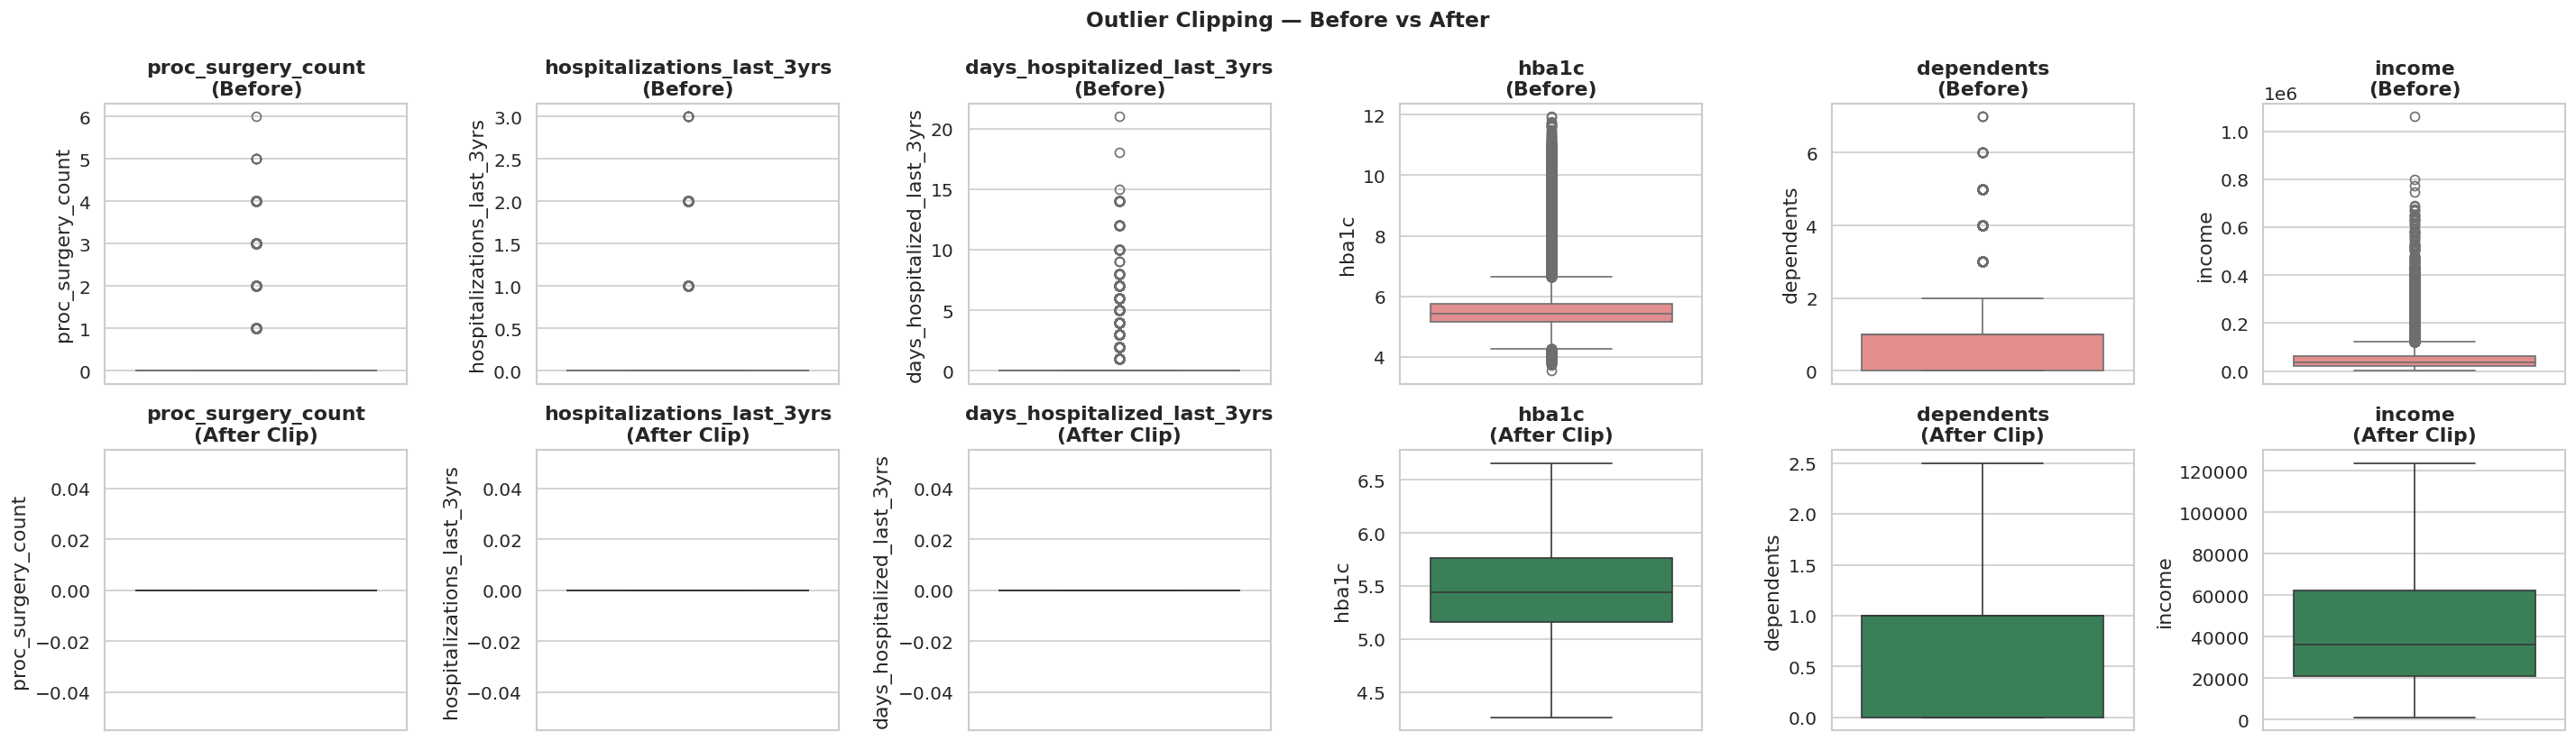

In [12]:
# Before/after visualization of the top 6 columns with the most outliers
top_out_cols = (
    outlier_df[outlier_df['Feature'].isin(NUM_COLS)]
    .nlargest(6, 'Outlier Count')['Feature'].tolist()
)

if top_out_cols:
    n = len(top_out_cols)
    fig, axes = plt.subplots(2, n, figsize=(4 * n, 7))
    for i, col in enumerate(top_out_cols):
        sns.boxplot(y=df[col],       ax=axes[0, i], color='lightcoral')
        axes[0, i].set_title(f'{col}\n(Before)')
        sns.boxplot(y=df_clean[col], ax=axes[1, i], color='seagreen')
        axes[1, i].set_title(f'{col}\n(After Clip)')
    plt.suptitle('Outlier Clipping — Before vs After', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../reports/figures/outlier_clipping.png', bbox_inches='tight')
    plt.show()

<a id='4'></a>
## 4. Target Transformation — Log

`annual_medical_cost` is right-skewed — a small number of high-cost patients
pull the distribution's tail. Applying `log1p` brings it closer to a normal
distribution, which improves model performance.

Models are trained on `log_cost` and predictions are converted back
to the original scale using `expm1` for interpretable evaluation metrics.

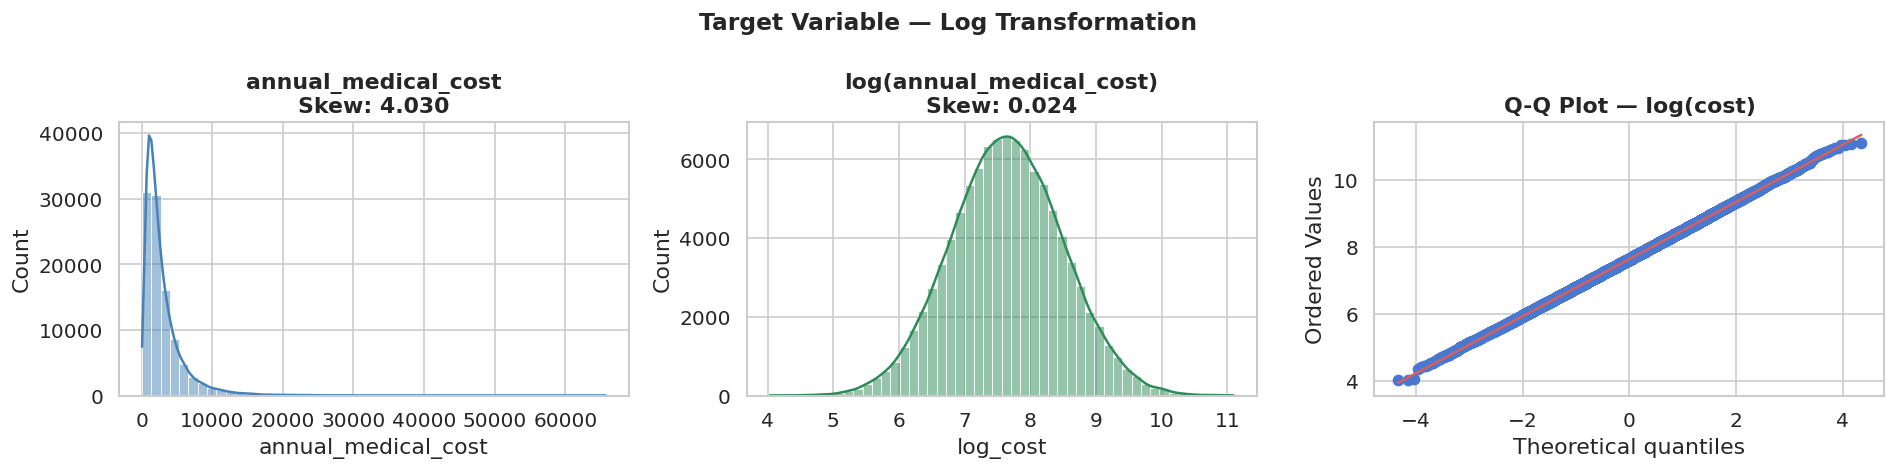

Orijinal skewness : 4.0303
Log skewness      : 0.0238


In [13]:
df_clean['log_cost'] = np.log1p(df_clean[TARGET])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(df_clean[TARGET], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title(f'annual_medical_cost\nSkew: {df_clean[TARGET].skew():.3f}')

sns.histplot(df_clean['log_cost'], bins=50, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title(f'log(annual_medical_cost)\nSkew: {df_clean["log_cost"].skew():.3f}')

stats.probplot(df_clean['log_cost'], dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot — log(cost)')

plt.suptitle('Target Variable — Log Transformation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/log_transform.png', bbox_inches='tight')
plt.show()

print(f'Orijinal skewness : {df_clean[TARGET].skew():.4f}')
print(f'Log skewness      : {df_clean["log_cost"].skew():.4f}')

<a id='5'></a>
## 5. Feature Engineering



In [14]:
df_fe = df_clean.copy()

# 1. BMI groups
df_fe['is_obese']       = (df_fe['bmi'] >= 30).astype(int)
df_fe['is_underweight'] = (df_fe['bmi'] < 18.5).astype(int)

# 2. Smoker flag (string -> binary)
is_smoker = (df_fe['smoker'].astype(str).str.lower().isin(['yes', '1', 'true'])).astype(int)
df_fe['smoker_flag']    = is_smoker
df_fe['smoker_bmi']     = is_smoker * df_fe['bmi']
df_fe['obese_smoker']   = df_fe['is_obese'] * is_smoker
df_fe['smoker_chronic'] = is_smoker * df_fe['chronic_count']

# 3. Age groups
df_fe['age_group'] = pd.cut(
    df_fe['age'],
    bins=[0, 30, 45, 60, 100],
    labels=[0, 1, 2, 3]   # Young / Middle-aged / Senior / Elderly
).astype(int)

# 4. Disease burden score
disease_cols = [
    'hypertension', 'diabetes', 'asthma', 'copd',
    'cardiovascular_disease', 'cancer_history',
    'kidney_disease', 'liver_disease', 'arthritis', 'mental_health'
]

df_fe['disease_burden'] = df_fe[disease_cols].sum(axis=1)

df_fe['diabetic_bmi'] = df_fe['diabetes'] * df_fe['bmi']

df_fe['high_bp'] = (
    (df_fe['systolic_bp'] >= 140) | (df_fe['diastolic_bp'] >= 90)
).astype(int)

# 5. Healthcare utilization intensity
proc_cols = [
    'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count',
    'proc_consult_count', 'proc_lab_count'
]

df_fe['total_procedures'] = df_fe[proc_cols].sum(axis=1)

df_fe['high_utilization'] = (
    (df_fe['visits_last_year'] > df_fe['visits_last_year'].quantile(0.75)) |
    (df_fe['hospitalizations_last_3yrs'] > 1)
).astype(int)

# 6. Deductible-to-income ratio
df_fe['deductible_to_income'] = df_fe['deductible'] / (df_fe['income'] + 1)

NEW_FEATURES = [
    'is_obese', 'is_underweight', 'smoker_flag', 'smoker_bmi', 'obese_smoker',
    'smoker_chronic', 'age_group', 'disease_burden', 'diabetic_bmi', 'high_bp',
    'total_procedures', 'high_utilization', 'deductible_to_income'
]

print(f'{len(NEW_FEATURES)} new features were created:')

for f in NEW_FEATURES:
    print(f'   + {f}')

13 new features were created:
   + is_obese
   + is_underweight
   + smoker_flag
   + smoker_bmi
   + obese_smoker
   + smoker_chronic
   + age_group
   + disease_burden
   + diabetic_bmi
   + high_bp
   + total_procedures
   + high_utilization
   + deductible_to_income




Rather than feeding raw columns directly into the model, we created new features
by combining and transforming existing ones — giving the model more meaningful signals to learn from.

| Feature | Logic |
|---------|-------|
| `is_obese`, `is_underweight` | BMI thresholds (≥30, <18.5) |
| `smoker_bmi`, `obese_smoker`, `smoker_chronic` | Smoking combined with BMI and chronic conditions |
| `age_group` | Age bucketed into 4 groups (young / middle / senior / elderly) |
| `disease_burden` | Sum of all 10 disease indicator columns |
| `high_bp` | Flag for systolic ≥ 140 or diastolic ≥ 90 |
| `diabetic_bmi` | Interaction between diabetes and BMI |
| `total_procedures` | Sum of all procedure count columns |
| `high_utilization` | Flag for patients with heavy hospital usage |
| `deductible_to_income` | Deductible as a proportion of income |

<a id='6'></a>
## 6. Encoding

In [22]:
# Check Unique Values
for col in CAT_COLS:
    print(f'{col:25s}: {df_fe[col].unique().tolist()}')

sex                      : ['Female', 'Male', 'Other']
region                   : ['North', 'Central', 'West', 'South', 'East']
urban_rural              : ['Suburban', 'Urban', 'Rural']
education                : ['Doctorate', 'No HS', 'HS', 'Some College', 'Masters', 'Bachelors']
marital_status           : ['Married', 'Single', 'Divorced', 'Widowed']
employment_status        : ['Retired', 'Employed', 'Self-employed', 'Unemployed']
smoker                   : ['Never', 'Current', 'Former']
plan_type                : ['PPO', 'POS', 'HMO', 'EPO']
network_tier             : ['Bronze', 'Gold', 'Platinum', 'Silver']
alcohol_freq             : [nan, 'Weekly', 'Daily', 'Occasional']


In [23]:
df_enc = df_fe.copy()

# Fill NaN — alcohol_freq
df_enc['alcohol_freq'] = df_enc['alcohol_freq'].fillna('Unknown')

# Drop leakage columns
df_enc.drop(columns=LEAKAGE_COLS, inplace=True, errors='ignore')

# Binary encoding
df_enc['sex_enc']   = (df_enc['sex'].str.lower() == 'male').astype(int)
df_enc['urban_enc'] = (df_enc['urban_rural'].str.lower() == 'urban').astype(int)
df_enc.drop(columns=['sex', 'urban_rural', 'smoker'], inplace=True)

# Ordinal encoding — education
edu_order = {
    'no hs'       : 0,
    'hs'          : 1,
    'some college': 2,
    'bachelors'   : 3,
    'masters'     : 4,
    'doctorate'   : 5
}
df_enc['education_enc'] = (
    df_enc['education'].str.lower().map(edu_order)
    .fillna(0)
    .astype(int)
)
df_enc.drop(columns=['education'], inplace=True)

# One-Hot encoding
ohe_cols = [
    'region', 'marital_status', 'employment_status',
    'plan_type', 'network_tier', 'alcohol_freq'
]
df_enc = pd.get_dummies(df_enc, columns=ohe_cols, drop_first=True, dtype=int)

In [24]:
print(f'Shape after encoding: {df_enc.shape}')
df_enc.head(3)

Shape after encoding: (100000, 74)


,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,systolic_bp,...,employment_status_Unemployed,plan_type_HMO,plan_type_POS,plan_type_PPO,network_tier_Gold,network_tier_Platinum,network_tier_Silver,alcohol_freq_Occasional,alcohol_freq_Unknown,alcohol_freq_Weekly
0,52.0,22700.0,3.0,1.0,27.4,2,0,0,4,121.0,...,0,0,0,1,0,0,0,0,1,0
1,79.0,12800.0,3.0,1.0,26.6,2,0,0,3,131.0,...,0,0,1,0,1,0,0,0,0,1
2,68.0,40700.0,4.5,2.5,31.5,1,0,0,4,159.5,...,0,1,0,0,0,1,0,0,1,0


<a id='7'></a>
## 7. Boruta — Feature Selection

### Boruta — Feature Selection

After encoding, the dataset contains a large number of features — not all of which
are genuinely useful. Boruta is a Random Forest-based wrapper method that identifies
truly relevant features by comparing each one against a shuffled shadow copy of itself.
Features that consistently outperform their shadow are confirmed; the rest are rejected.

In [28]:
DROP_FOR_MODEL = [TARGET, 'log_cost']
feature_names  = [c for c in df_enc.columns if c not in DROP_FOR_MODEL]

X_boruta = df_enc[feature_names].values
y_boruta = df_enc['log_cost'].values

print(f'Number of features entering Boruta: {len(feature_names)}')

rf_boruta = RandomForestRegressor(
    n_estimators=100,
    max_depth=7,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

boruta_selector = BorutaPy(
    estimator=rf_boruta,
    n_estimators='auto',
    max_iter=50,
    random_state=RANDOM_STATE,
    verbose=1
)

boruta_selector.fit(X_boruta, y_boruta)
print('\nBoruta completed successfully.')

Number of features entering Boruta: 72
Iteration: 1 / 50
Iteration: 2 / 50
Iteration: 3 / 50
Iteration: 4 / 50
Iteration: 5 / 50
Iteration: 6 / 50
Iteration: 7 / 50
Iteration: 8 / 50
Iteration: 9 / 50
Iteration: 10 / 50
Iteration: 11 / 50
Iteration: 12 / 50
Iteration: 13 / 50
Iteration: 14 / 50
Iteration: 15 / 50
Iteration: 16 / 50
Iteration: 17 / 50
Iteration: 18 / 50
Iteration: 19 / 50


BorutaPy finished running.

Iteration: 	20 / 50
Confirmed: 	8
Tentative: 	0
Rejected: 	64

Boruta completed successfully.


In [29]:
boruta_results = pd.DataFrame({
    'Feature'  : feature_names,
    'Confirmed': boruta_selector.support_,
    'Tentative': boruta_selector.support_weak_,
    'Ranking'  : boruta_selector.ranking_
}).sort_values('Ranking')

boruta_results['Status'] = boruta_results.apply(
    lambda r: 'Confirmed' if r['Confirmed'] else
              ('Tentative' if r['Tentative'] else 'Rejected'),
    axis=1
)

print(f"Confirmed : {boruta_results['Confirmed'].sum()}")
print(f"Tentative : {boruta_results['Tentative'].sum()}")
print(f"Rejected  : {(~boruta_results['Confirmed'] & ~boruta_results['Tentative']).sum()}")
display(boruta_results[['Feature', 'Status', 'Ranking']].reset_index(drop=True))

Confirmed : 8
Tentative : 0
Rejected  : 64


,Feature,Status,Ranking
0,age,Confirmed,1
1,bmi,Confirmed,1
2,visits_last_year,Confirmed,1
3,provider_quality,Confirmed,1
4,risk_score,Confirmed,1
...,...,...,...
67,obese_smoker,Rejected,61
68,hospitalizations_last_3yrs,Rejected,61
69,days_hospitalized_last_3yrs,Rejected,61
70,policy_changes_last_2yrs,Rejected,61


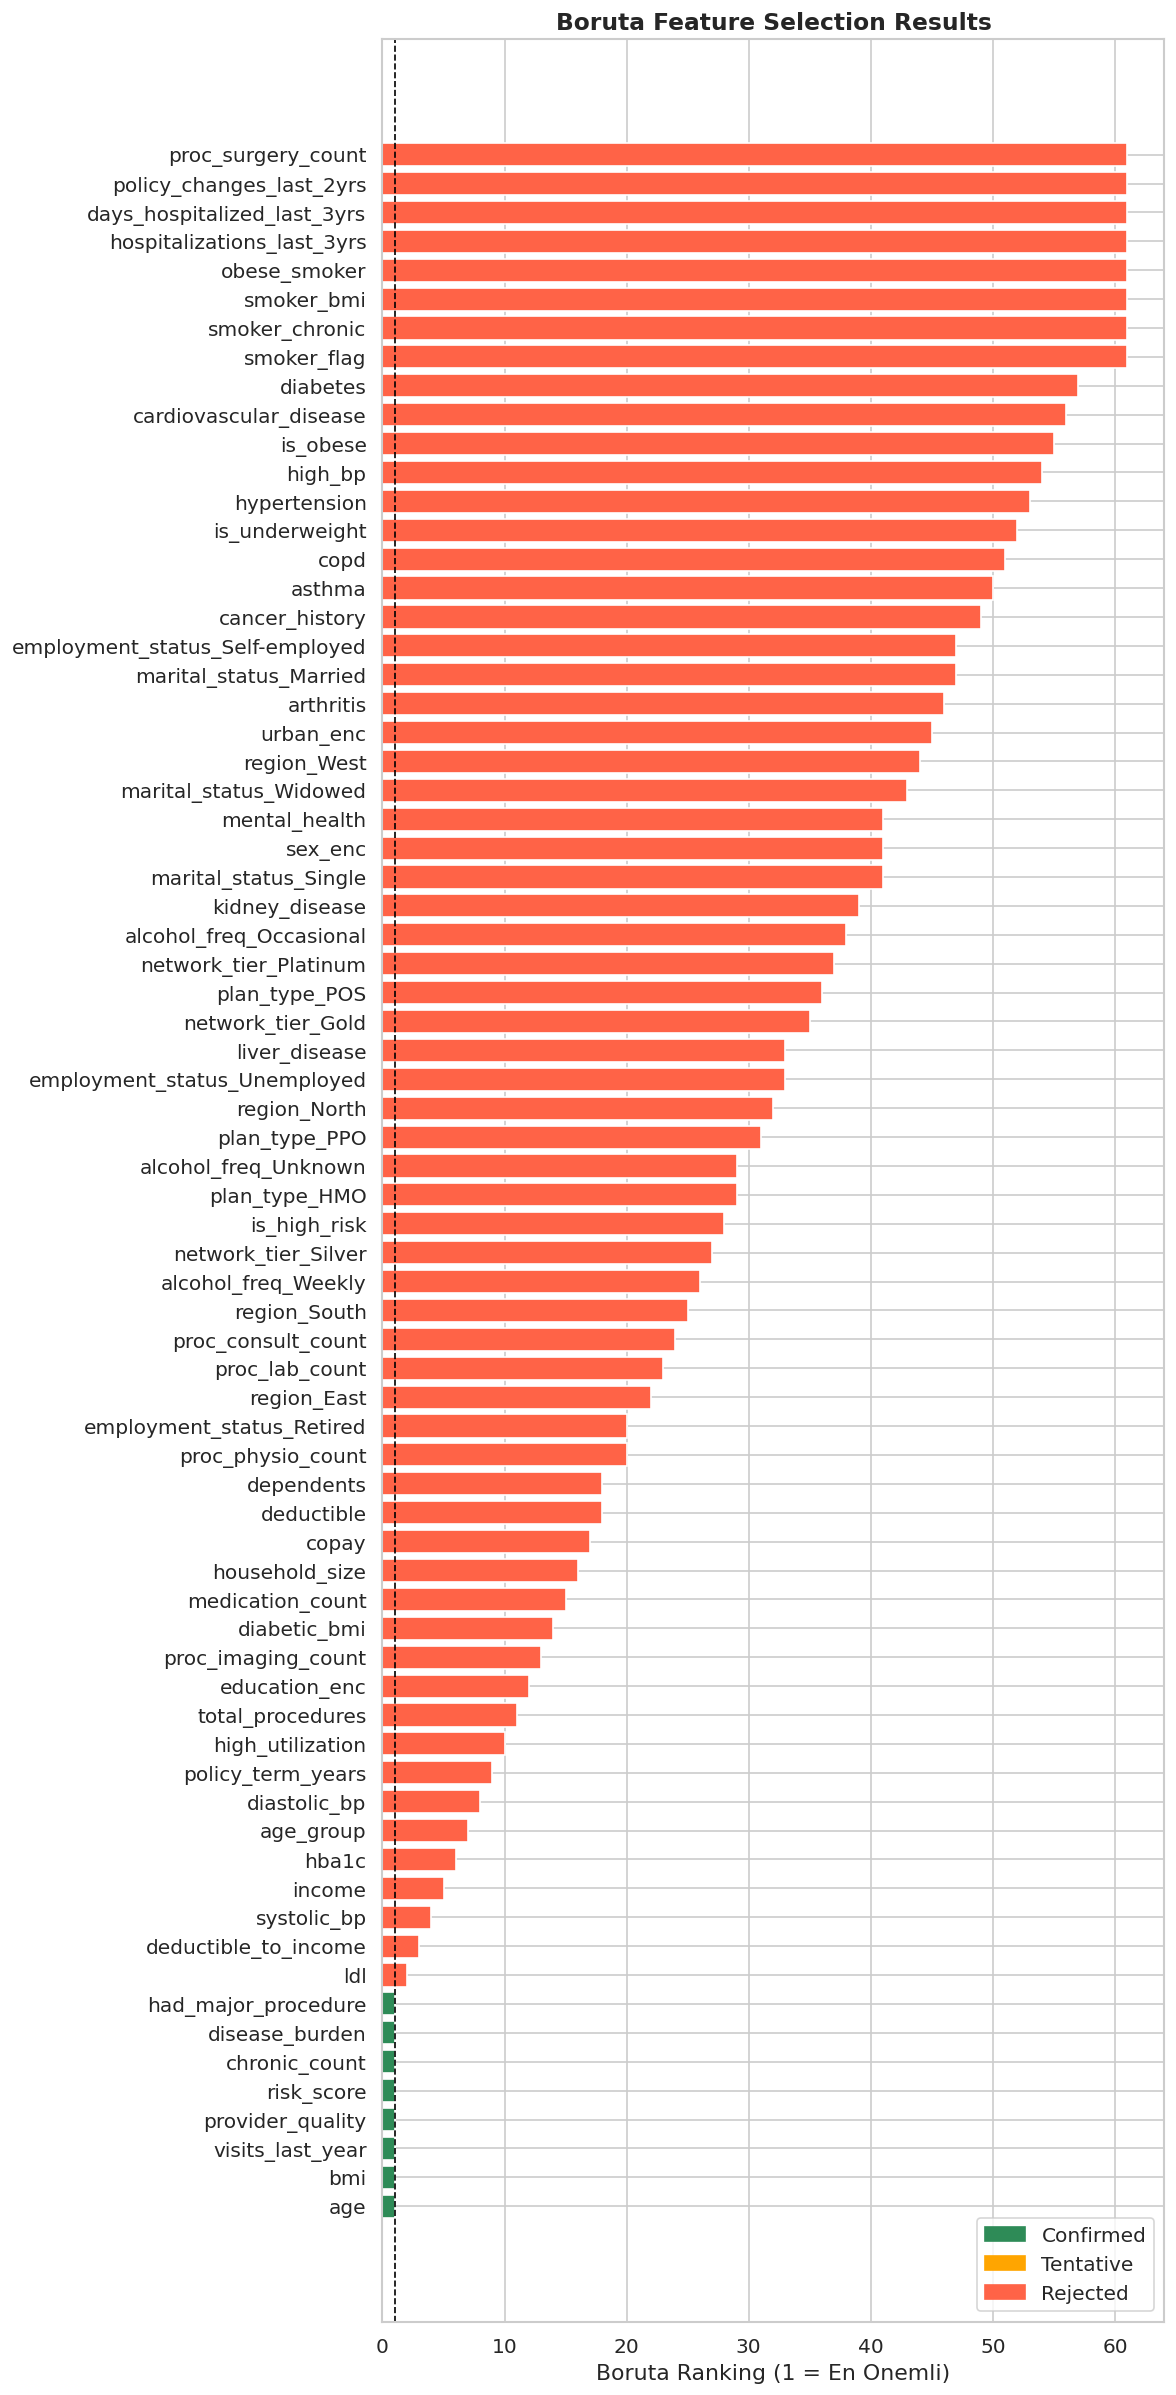

In [32]:
fig, ax = plt.subplots(figsize=(10, max(6, len(feature_names) * 0.28)))

color_map = {'Confirmed': 'seagreen', 'Tentative': 'orange', 'Rejected': 'tomato'}
colors = boruta_results['Status'].map(color_map)

ax.barh(boruta_results['Feature'], boruta_results['Ranking'],
        color=colors, edgecolor='white')
ax.axvline(1, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Boruta Ranking (1 = En Onemli)')
ax.set_title('Boruta Feature Selection Results', fontsize=14, fontweight='bold')

legend = [
    Patch(color='seagreen', label='Confirmed'),
    Patch(color='orange',   label='Tentative'),
    Patch(color='tomato',   label='Rejected')
]
ax.legend(handles=legend, loc='lower right')
plt.tight_layout()
plt.savefig('../reports/figures/boruta_results.png', bbox_inches='tight')
plt.show()

In [34]:
SELECTED_FEATURES = boruta_results[
    boruta_results['Confirmed'] | boruta_results['Tentative']
]['Feature'].tolist()

print(f'Initial number of features : {len(feature_names)}')
print(f'After Boruta selection     : {len(SELECTED_FEATURES)}')
print(f'\nSelected features:')
for f in SELECTED_FEATURES:
    print(f'   + {f}')

Initial number of features : 72
After Boruta selection     : 8

Selected features:
   + age
   + bmi
   + visits_last_year
   + provider_quality
   + risk_score
   + chronic_count
   + disease_burden
   + had_major_procedure


### Boruta Results — Interpretation

Out of 72 features, Boruta confirmed only **8 as genuinely relevant** to predicting
`annual_medical_cost`. The remaining 64 were rejected as no better than random noise.

| Feature | Why it matters |
|---------|---------------|
| `age` | Medical costs consistently increase with age |
| `bmi` | Higher BMI is strongly associated with chronic conditions and higher costs |
| `visits_last_year` | Frequent visits are a direct indicator of ongoing medical needs |
| `provider_quality` | Higher quality providers tend to correlate with more comprehensive (costly) care |
| `risk_score` | A composite health risk metric — higher score means higher expected cost |
| `chronic_count` | More chronic conditions directly drive higher medical spending |
| `disease_burden` | Total number of diagnosed diseases — captures overall health complexity |
| `had_major_procedure` | Major procedures are among the largest cost drivers in healthcare |

> Notably, smoking-related features (`smoker_flag`, `smoker_bmi`, `obese_smoker`)
> were rejected — likely because their effect is already captured by `risk_score`
> and `chronic_count`, which are composite health indicators.

<a id='8'></a>
## 8. Train / Test Split

In [38]:
X     = df_enc[SELECTED_FEATURES]
y     = df_enc['log_cost']
y_raw = df_enc[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

y_train_raw = y_raw.loc[y_train.index]
y_test_raw  = y_raw.loc[y_test.index]

print(f'Train set: {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set : {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'Number of features: {X_train.shape[1]}')

print(f'\nTarget distribution (log_cost):')
print(y_train.describe().round(3))

Train set: 80,000 rows (80%)
Test set : 20,000 rows (20%)
Number of features: 8

Target distribution (log_cost):
count    80000.000
mean         7.644
std          0.852
min          4.035
25%          7.070
50%          7.641
75%          8.216
max         11.093
Name: log_cost, dtype: float64


<a id='9'></a>
## 9. Feature Scaling

> Tree modeller unscaled veri kullanir.  
> Linear modeller (Ridge, Lasso, SVR) icin scaled versiyon ayrica kaydedilir.  
> Scaler sadece train setine fit edilir — **data leakage yok.**

In [39]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=SELECTED_FEATURES, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=SELECTED_FEATURES, index=X_test.index
)

print('StandardScaler fit: applied only to the training set (no data leakage).')
X_train_scaled.describe().round(3)

StandardScaler fit: applied only to the training set (no data leakage).


,age,bmi,visits_last_year,provider_quality,risk_score,chronic_count,disease_burden,had_major_procedure
count,80000.000,80000.000,80000.000,80000.000,80000.000,80000.000,80000.000,80000.000
mean,0.000,0.000,0.000,0.000,0.000,-0.000,0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-2.646,-2.735,-1.199,-2.732,-2.076,-0.934,-0.899,-0.451
25%,-0.665,-0.683,-0.560,-0.675,-0.760,-0.934,-0.899,-0.451
50%,0.026,0.001,0.078,0.002,-0.059,0.389,0.344,-0.451
75%,0.655,0.685,0.717,0.695,0.730,0.389,0.344,-0.451
max,2.636,2.738,2.632,2.371,1.915,2.373,6.562,2.217


<a id='10'></a>
## 10. Save Processed Data

In [41]:
# Splits — unscaled (tree modeller)
X_train.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv',   index=False)

# Splits — scaled (linear modeller)
X_train_scaled.to_csv('../data/processed/X_train_scaled.csv', index=False)
X_test_scaled.to_csv('../data/processed/X_test_scaled.csv',   index=False)

# Target
y_train.to_csv('../data/processed/y_train.csv',         index=False)
y_test.to_csv('../data/processed/y_test.csv',           index=False)
y_train_raw.to_csv('../data/processed/y_train_raw.csv', index=False)
y_test_raw.to_csv('../data/processed/y_test_raw.csv',   index=False)

# Full processed
df_enc.to_csv('../data/processed/insurance_processed.csv', index=False)

# Artefacts
joblib.dump(scaler,            '../models/scaler.pkl')
joblib.dump(SELECTED_FEATURES, '../models/selected_features.pkl')
joblib.dump(boruta_selector,   '../models/boruta_selector.pkl')

print('\n── data/processed/ ')
for f in sorted(os.listdir('../data/processed/')):
    size = os.path.getsize(f'../data/processed/{f}') / 1024
    print(f'   {f:<42} {size:.1f} KB')


── data/processed/ 
   X_test.csv                                 621.4 KB
   X_test_scaled.csv                          3081.5 KB
   X_train.csv                                2485.5 KB
   X_train_scaled.csv                         12328.5 KB
   insurance_processed.csv                    24258.6 KB
   y_test.csv                                 350.4 KB
   y_test_raw.csv                             151.2 KB
   y_train.csv                                1401.7 KB
   y_train_raw.csv                            604.8 KB
